In [50]:
# imports
import os
import requests
from pathlib import Path
import zipfile
import random
from typing import List, Tuple

# torch baseline
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# torchvision baseline
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from PIL import Image

# metrics and progress bar
import tqdm.auto as tqdm
try:
  from torchinfo import summary
except:
  !pip install -q torchinfo
  from torchinfo import summary
try:
  import torchmetrics
  from torchmetrics import Accuracy, ConfusionMatrix
except:
  !pip install -q torchmetrics
  import torchmetrics
  from torchmetrics import Accuracy, ConfusionMatrix

# numpy
import numpy as np

# making plots
import matplotlib.pyplot as plt

device = torch.device(
    "mps"
     if torch.backends.mps.is_available()
     else "cuda"
     if torch.cuda.is_available()
     else "cpu"
)

print("All imported.")
print(device)

All imported.
cuda


In [51]:
# downloading data
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir() and len(os.listdir(image_path)) > 0:
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...\n")
  image_path.mkdir(parents=True, exist_ok=True)
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print(f"Downloading pizza_steak_sushi data in {image_path} directory\n")
    f.write(request.content)
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print(f"Unzipping pizza_steak_sushi.zip data in {image_path} directory")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


In [52]:
# function for display structure data
def walk_trought_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [53]:
walk_trought_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak.
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza.
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak.
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza.
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi.


In [54]:
# determining paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/train/steak/2878151.jpg
Image class: steak
Width image: 512
Height image: 512


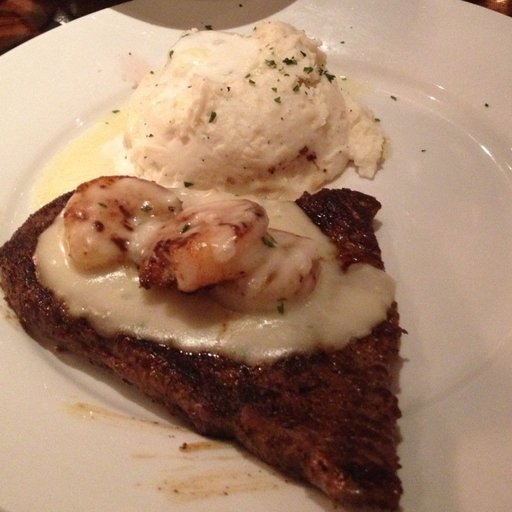

In [55]:
# visualisated sample v1 (with PIL.Image)
random.seed(2026)
image_samples = list(train_dir.glob("*/*.jpg"))
sample = random.choice(image_samples)
class_sample = sample.parent.stem
img = Image.open(sample)
print(f"Random image path: {sample}")
print(f"Image class: {class_sample}")
print(f"Width image: {img.width}")
print(f"Height image: {img.height}")
img

Random image path: data/pizza_steak_sushi/train/steak/2878151.jpg
Width image: 512
Height image: 512


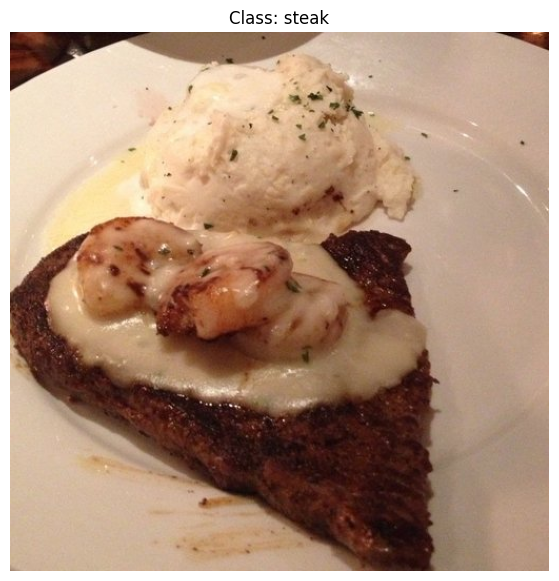

In [56]:
# visualisated sample v2 (with numpy)
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.title(f"Class: {class_sample}")
plt.axis(False)

print(f"Random image path: {sample}")
print(f"Width image: {img.width}")
print(f"Height image: {img.height}")

plt.show()

In [57]:
# simple transforms for baseline model
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [58]:
# creating datasets from our data
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transform,
                                 target_transform=None)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [59]:
# display data labels
print(train_data.classes)
print(train_data.class_to_idx)

['pizza', 'steak', 'sushi']
{'pizza': 0, 'steak': 1, 'sushi': 2}


In [60]:
# creating fucntion for visualisated samples in our datasets
def plot_images(data: torch.utils.data,
                n=3,
                seed=2026):
  random.seed(seed)
  random_indices = random.sample(range(len(data)), k=n)

  fig, axes = plt.subplots(1, n, figsize=(n*3, 3))

  for ax, index in zip(axes, random_indices):
    image, label = data[index]
    class_names = data.classes[label]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Class: {class_names}", fontsize=15)
    ax.axis(False)

  plt.tight_layout()
  plt.show();

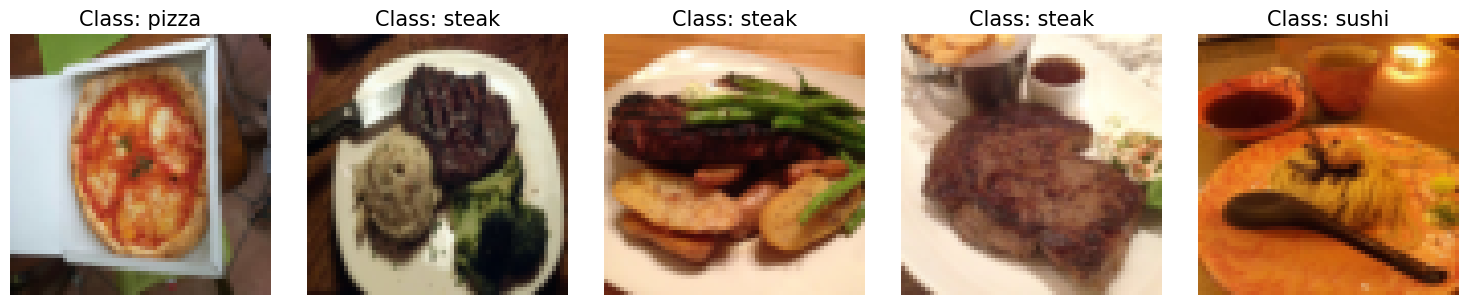

In [61]:
# present 5 examples
plot_images(data=train_data,
            n=5,
            seed=2026)

In [62]:
# display one example
image, label = train_data[0][0], train_data[0][1]
print(f"Image: {image}")
print(f"Label: {label}")
print(f"Shape: {image.shape}")

Image: tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0902, 0.0

In [63]:
# creating batches
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x797669e5fbb0>,
 <torch.utils.data.dataloader.DataLoader at 0x797669e75b50>)

In [64]:
# create function for display images from batches
def plot_images_batch(dataloader: torch.utils.data,
                n=3,
                seed=2026):
  random.seed(seed)
  image_batch, label_batch = next(iter(dataloader))
  batch_size = image_batch.shape[0]
  random_indices = random.sample(range(batch_size), k=min(n, batch_size))

  fig, axes = plt.subplots(1, n, figsize=(n*3, 3))
  class_names = dataloader.dataset.classes

  if n == 1:
    axes = [axes]
  for ax, index in zip(axes, random_indices):
    image = image_batch[index]
    label = label_batch[index].item()
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Class: {class_names[label]}", fontsize=15)
    ax.axis(False)

  plt.tight_layout()
  plt.show();

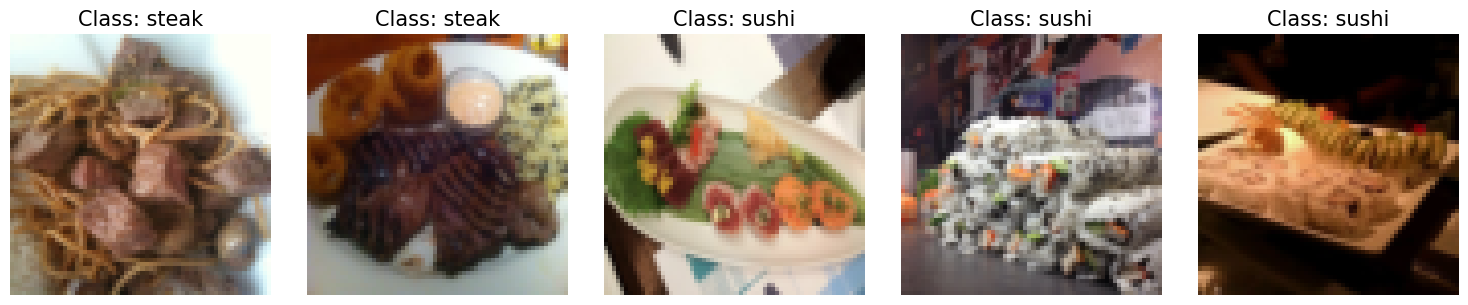

In [65]:
# display 5 examples
plot_images_batch(dataloader=train_dataloader,
                  n=5,
                  seed=2026)

In [66]:
# create function for find labels in data
def find_class(directory: str):
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn`t find any classes in {directory}.")
  else:
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx

In [67]:
# create a custom dataset loader
class ImageFolderCustom(Dataset):
  def __init__(self, targ_dir: str, transform=None):
    self.paths = list(Path(targ_dir).glob("*/*.jpg"))
    self.transform = transform
    self.classes, self.class_to_idx = find_class(targ_dir)
  def load_image(self, index: int):
    image_path = self.paths[index]
    return Image.open(image_path)
  def __len__(self):
    return len(self.paths)
  def __getitem__(self, index: int):
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]
    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx

In [68]:
# transforms for custonm data
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [69]:
# determine a custom dataset loader
train_data = ImageFolderCustom(targ_dir=train_dir,
                               transform=train_transform)
test_data = ImageFolderCustom(targ_dir=test_dir,
                              transform=test_transform)

train_data, test_data

(<__main__.ImageFolderCustom at 0x79766a165a90>,
 <__main__.ImageFolderCustom at 0x797669b782d0>)

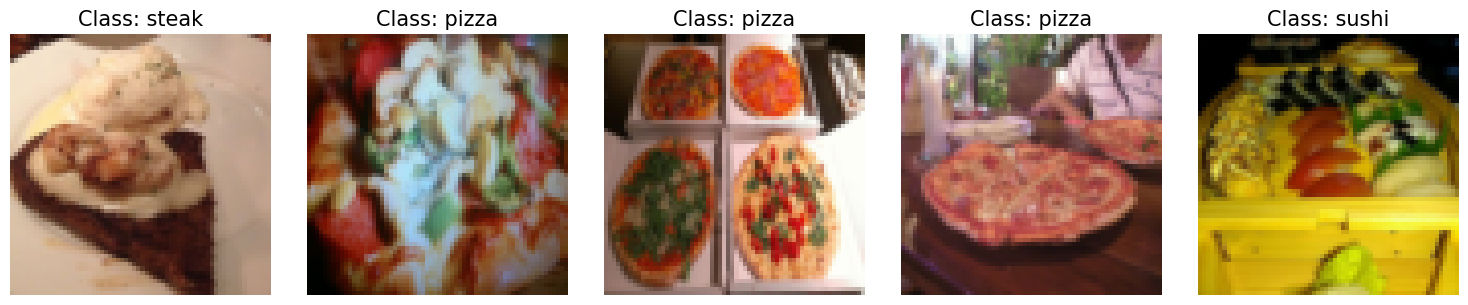

In [70]:
# display 5 examples from custom datasets
plot_images(data=train_data,
            n=5,
            seed=2026)

In [71]:
# display one sample from custom dataset
image, label = train_data[0][0], train_data[0][1]
print(f"Image: {image}")
print(f"Label: {label}")
print(f"Shape: {image.shape}")

Image: tensor([[[0.8745, 0.8902, 0.9333,  ..., 0.6980, 0.7608, 0.8353],
         [0.8902, 0.9373, 0.9647,  ..., 0.7529, 0.6667, 0.6196],
         [0.9412, 0.9686, 0.9843,  ..., 0.9255, 0.9137, 0.8863],
         ...,
         [0.5647, 0.5490, 0.5451,  ..., 0.3137, 0.3098, 0.3059],
         [0.5176, 0.5137, 0.5255,  ..., 0.3176, 0.3098, 0.3020],
         [0.4824, 0.4902, 0.5059,  ..., 0.3059, 0.3059, 0.3059]],

        [[0.6549, 0.6667, 0.6980,  ..., 0.4588, 0.5216, 0.5922],
         [0.6549, 0.6941, 0.7137,  ..., 0.5137, 0.4118, 0.3569],
         [0.6941, 0.7137, 0.7333,  ..., 0.6863, 0.6667, 0.6275],
         ...,
         [0.2667, 0.2549, 0.2431,  ..., 0.0784, 0.0745, 0.0745],
         [0.2235, 0.2196, 0.2275,  ..., 0.0784, 0.0706, 0.0706],
         [0.2118, 0.2078, 0.2157,  ..., 0.0706, 0.0706, 0.0706]],

        [[0.4235, 0.4392, 0.4706,  ..., 0.2275, 0.2745, 0.3216],
         [0.4196, 0.4627, 0.4784,  ..., 0.2588, 0.1882, 0.1569],
         [0.4510, 0.4745, 0.4902,  ..., 0.3804, 0.3

In [72]:
# create custom neural network with public architecture
class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2),
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,
                  out_features=output_shape)
    )
  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

model = TinyVGG(input_shape=3,
                output_shape=len(train_data.classes),
                hidden_units=10).to(device)
model

TinyVGG(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [73]:
# display the custom archihectural model
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary

summary = summary(model, input_size=[32, 3, 64, 64])
summary

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

In [74]:
# create a training function
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  train_loss, train_acc = 0, 0
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_loggits = model(X)

    loss = loss_fn(y_loggits, y)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred = torch.argmax(torch.softmax(y_loggits, dim=1), dim=1)
    train_acc += (y_pred == y).sum().item()/len(y_loggits)
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [75]:
# create a function to evaluate on the test set
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  test_loss, test_acc = 0, 0
  model.eval()

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_loggits = model(X)
    loss = loss_fn(y_loggits, y)
    test_loss += loss.item()
    test_pred = torch.argmax(y_loggits, dim=1)
    test_acc += (test_pred == y).sum().item()/len(y_loggits)
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [76]:
# full function (train_step + test_step)
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5):

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  for epoch in range(epochs):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    print(
        f"Epoch: {epoch+1}",
        f"Train Loss: {train_loss:.3f}",
        f"Train Accuracy: {train_acc:.3f}",
        f"Test Loss: {test_loss:.3f}",
        f"Test Accuaracy: {test_acc:.3f}"
    )

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
  return results

In [77]:
# model training and evaluation on the test set
from timeit import default_timer as timer

torch.manual_seed(2026)
start_time = timer()
NUM_EPOCHS = 20

model = TinyVGG(input_shape=3,
                output_shape=len(train_data.classes),
                hidden_units=20).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

model_results = train(model,
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Epoch: 1 Train Loss: 1.122 Train Accuracy: 0.191 Test Loss: 1.099 Test Accuaracy: 0.198
Epoch: 2 Train Loss: 1.099 Train Accuracy: 0.305 Test Loss: 1.099 Test Accuaracy: 0.281
Epoch: 3 Train Loss: 1.104 Train Accuracy: 0.293 Test Loss: 1.100 Test Accuaracy: 0.292
Epoch: 4 Train Loss: 1.096 Train Accuracy: 0.379 Test Loss: 1.089 Test Accuaracy: 0.552
Epoch: 5 Train Loss: 1.095 Train Accuracy: 0.477 Test Loss: 1.080 Test Accuaracy: 0.562
Epoch: 6 Train Loss: 1.109 Train Accuracy: 0.289 Test Loss: 1.045 Test Accuaracy: 0.552
Epoch: 7 Train Loss: 1.071 Train Accuracy: 0.461 Test Loss: 1.107 Test Accuaracy: 0.271
Epoch: 8 Train Loss: 1.072 Train Accuracy: 0.305 Test Loss: 1.164 Test Accuaracy: 0.312
Epoch: 9 Train Loss: 0.992 Train Accuracy: 0.523 Test Loss: 1.173 Test Accuaracy: 0.302
Epoch: 10 Train Loss: 1.012 Train Accuracy: 0.406 Test Loss: 1.041 Test Accuaracy: 0.465
Epoch: 11 Train Loss: 1.136 Train Accuracy: 0.438 Test Loss: 1.107 Test Accuaracy: 0.312
Epoch: 12 Train Loss: 0.985 Tr

In [78]:
# save model weights
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_TinyVGG_model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saves weights model in {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

Saves weights model in models/01_TinyVGG_model


In [79]:
# custom version
# manual_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [80]:
# initialize weights from the public model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [81]:
# borrow transforms from the weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [82]:
# create a dataset loader
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=auto_transforms,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=auto_transforms,
                                 target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: ImageClassification(
                crop_size=[224]
                resize_size=[256]
                mean=[0.485, 0.456, 0.406]
                std=[0.229, 0.224, 0.225]
                interpolation=InterpolationMode.BICUBIC
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: ImageClassification(
                crop_size=[224]
                resize_size=[256]
                mean=[0.485, 0.456, 0.406]
                std=[0.229, 0.224, 0.225]
                interpolation=InterpolationMode.BICUBIC
            ))

In [83]:
# create batches
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=os.cpu_count())
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True,
                             num_workers=os.cpu_count())

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x797669e67680>,
 <torch.utils.data.dataloader.DataLoader at 0x797669e67bd0>)

In [84]:
# repeat initialize weights and transfer in device
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [85]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [87]:
# look at the model architecture
from torchinfo import summary

model_summary = summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

model_summary

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [88]:
# freezing weights
for param in model.features.parameters():
  param.requires_grad = False

In [89]:
# edit model output layer
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(train_data.classes)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

In [90]:
# look at the new model architecture
model_summary = summary(model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)
model_summary

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [91]:
# training a model and evaulate on test
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 20

from timeit import default_timer as timer
start_time = timer()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=NUM_EPOCHS)

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Epoch: 1 Train Loss: 1.092 Train Accuracy: 0.398 Test Loss: 0.880 Test Accuaracy: 0.659
Epoch: 2 Train Loss: 0.853 Train Accuracy: 0.801 Test Loss: 0.741 Test Accuaracy: 0.896
Epoch: 3 Train Loss: 0.810 Train Accuracy: 0.695 Test Loss: 0.673 Test Accuaracy: 0.876
Epoch: 4 Train Loss: 0.714 Train Accuracy: 0.758 Test Loss: 0.644 Test Accuaracy: 0.856
Epoch: 5 Train Loss: 0.623 Train Accuracy: 0.766 Test Loss: 0.576 Test Accuaracy: 0.876
Epoch: 6 Train Loss: 0.609 Train Accuracy: 0.781 Test Loss: 0.567 Test Accuaracy: 0.876
Epoch: 7 Train Loss: 0.538 Train Accuracy: 0.898 Test Loss: 0.501 Test Accuaracy: 0.866
Epoch: 8 Train Loss: 0.549 Train Accuracy: 0.766 Test Loss: 0.477 Test Accuaracy: 0.856
Epoch: 9 Train Loss: 0.509 Train Accuracy: 0.781 Test Loss: 0.473 Test Accuaracy: 0.866
Epoch: 10 Train Loss: 0.494 Train Accuracy: 0.793 Test Loss: 0.455 Test Accuaracy: 0.876
Epoch: 11 Train Loss: 0.473 Train Accuracy: 0.816 Test Loss: 0.450 Test Accuaracy: 0.855
Epoch: 12 Train Loss: 0.418 Tr

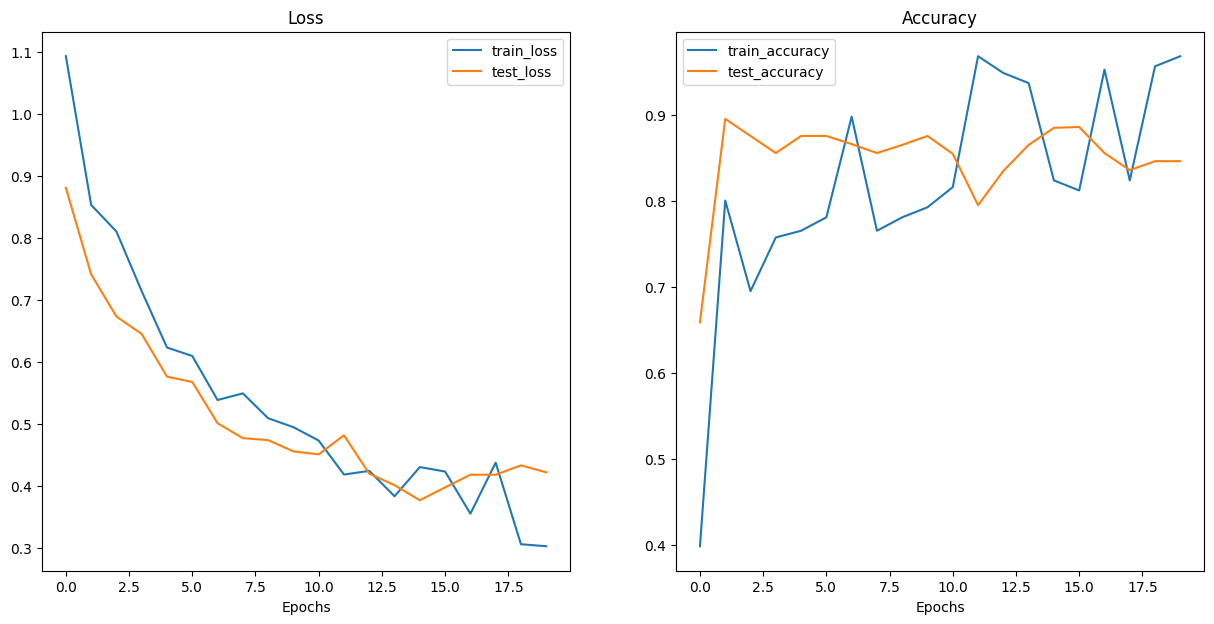

In [92]:
# look at the curves loss
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

plot_loss_curves(results)

In [93]:
# create function for predcition and plotting
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

  img = Image.open(image_path)
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
  model.to(device)
  model.eval()
  with torch.inference_mode():
    transformed_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(transformed_image.to(device))
  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False)

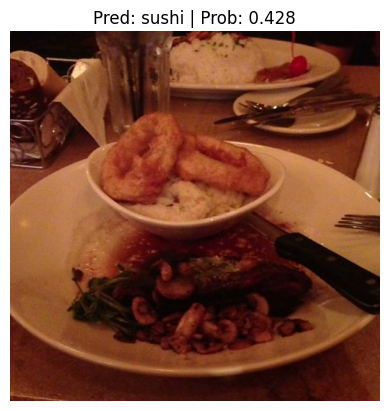

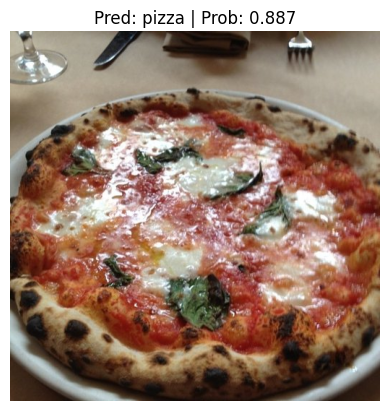

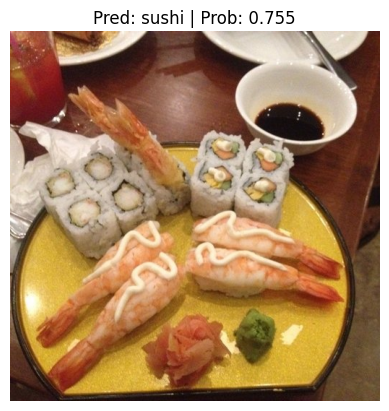

In [94]:
# prediction and visualisated on test
class_names = train_data.classes
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot)

for image_path in test_image_path_sample:
  pred_and_plot_image(model=model,
                      image_path=image_path,
                      class_names=class_names,
                      image_size=(224, 224))

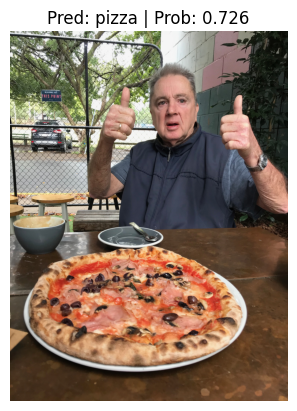

In [95]:
# predict on the public image
custom_image_path = data_path / "04-pizza-dad.jpeg"

if custom_image_path.exists():
  custom_image_path.unlink()

if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists, skipping download.")

pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)